# Framestack theta survey — population θ distribution of stationary rods

**Goal (camera paper):** from full-frame `frame_stack_*.npy` recordings, detect all
*stationary* rods, extract one θ per rod (median over frames), and build the
population θ distribution.

**Physics expectation:**
- bare rods stuck on glass → lie flat → **θ ≈ 90°** (saturating the anisotropy ring)
- rods on DNA hinges → held at the hinge's open angle → **θ peaks at discrete hinge angles**
- so a θ-histogram of many rods is the "DNA vs bare" discriminator, and the number of
  rods-at-θ is the population statistic (the camera paper's throughput demo).

**Spot detection = Hugh's auto detector** (`Detection_alg_offline.py`,
`find_spot_centers_dog`), transplanted from his spinner GUI: DoG blob detection
(σ = 1.0 − 6.0 px) on the **static S-map** (per-pixel polarised intensity, median
over 80 frames) → 8σ threshold → 8-connected components → **area filter 10–250 px**.
Adaptations for stationary rods (documented in section 1): static S-map blend
(`a=1.0`; Hugh's default `a=0` is a change metric for *moving* spinners), robust
threshold σ, block-level despiking.

**The DC gate (important — learned from the first real-data run, 2026-09-25):** on a
full frame the S-map also lights up **residual sensor polarisation fixed pattern** —
the four pixels of each 2×2 block have slightly different offsets, so every block
carries a static Q = d0 − d90 ≠ 0 while its DC (I0+I90) is ≈ 0 after background
subtraction. Those blobs pass any polarisation threshold, and their anisotropy is
noise/noise → r ≥ r_max → **θ clipped at exactly 90° with a tight IQR** — a fake
"bare rod" population of thousands. A real rod is *bright*: its pair-sums are
hundreds of counts above bg. Two gates encode that: `MIN_SPOT_AMP` (mean-image
intensity, applied before extraction) and `DC_MIN` (per-frame pair-sum, marks frames
invalid → spots fail as `LOWDC`). Tune both from the section-3 quantile printout and
the DC-vs-θ diagnostic plot — the junk sits at DC ≈ 0, real rods separate cleanly.

**Memory safety:** files are GB-scale — everything runs on `np.load(mmap_mode='r')`
with chunked frame processing; only the S-map (~400 MB for 80 frames at full frame
size) and per-spot accumulators are held in RAM.

**Validated on a synthetic 60-frame stack** (14 stationary rods θ = 5–85°, 2 movers,
a 2-rod aggregate, 25 hot pixels, illumination gradient): detection 16/16 stationary
rods, 0 false detections, movers excluded; θ mean |error| ≈ 9° at 60 frames
(shrinks ∝ 1/√N_frames). Note the synthetic *understates* the fixed-pattern problem —
real sensor backgrounds are exactly where the DC gate earns its keep.

In [34]:
# ============ CONFIG ============
FOLDER = r"data\framestack"     # folder containing frame_stack_*.npy + .json
FILE_PATTERN = "frame_stack_*.npy"
OUTPUT_DIR = "framestack_survey_out"

# --- Hugh's auto spot detection (Detection_alg_offline.py defaults) ---
S_MAP_FRAMES = 80         # frames sampled (uniformly across the stack) for the S-map
S_MAP_SMOOTH_K = 5        # box smooth of the S-map before DoG
EDGE_EXCLUDE_PX = 10      # ignore this border (Hugh's EDGE_EXCLUDE_PX)
DOG_SIGMA_SMALL = 1.0     # DoG small Gaussian sigma (px)
DOG_SIGMA_LARGE = 6.0     # DoG large Gaussian sigma (px)
DOG_K_STD = 8.0           # threshold = 0 + k std above the DoG baseline
DOG_MIN_AREA = 10         # px, blobs smaller are hot pixels
DOG_MAX_AREA = 250        # px, blobs larger are debris/aggregates
DESPIKE_RATIO = 20.0      # S-map block > 20x its 3x3 median = hot pixel, replace
USE_ROBUST_THRESHOLD = True   # median + k*1.4826*MAD; False = Hugh's exact mean + k*std

# --- large-blob pass (Hugh's DoG is band-passed to 3-15 px spots and MISSES big
#     smooth blobs like defocused rods/aggregates; this second pass catches them) ---
BIG_SIGMA = 8.0           # px, smoothing sigma of the S-map for the large pass
BIG_FOOTPRINT = 21        # px, non-maximum-suppression window (one position per blob)
BIG_K = 8.0               # threshold = k robust sigmas of the smoothed S-map
BIG_HALF = 7              # px, MINIMUM extraction crop half-width for large blobs
BIG_HALF_MAX = 16         # px, cap (crop/annulus scale with the blob footprint, see spot_halves)

# --- gates (kill the fake populations; tune from the section-3 printout) ---
# A real rod is BRIGHT and POLARISED. Residual sensor polarisation fixed pattern
# has Q = d0 - d90 != 0 while I0+I90 ~ 0 after bg subtraction -> ax = noise/noise
# -> r >= r_max -> theta clips at exactly 90 deg with a TIGHT IQR (mimics a perfect
# "bare rod" population). And a spot with r ~ 0 has no meaningful theta at all.
MIN_SPOT_AMP = 100        # counts, min intensity amplitude above bg (mean image) to extract a spot at all
DC_MIN = 100.0            # counts, min (I0+I90) and (I45+I135) crop mean for a theta frame to count as VALID
MIN_R = 0.1               # min mean anisotropy radius; below this theta is undefined (quality NOPOL)

# --- extraction ---
CROP_HALF = 3             # px, half-width of the spot extraction crop (odd window = 2*3+1)
ANNULUS_WIDTH = 3         # px, background annulus width beyond the crop
DRIFT_TOL = 1.5           # px, max displacement between first/second-half mean to count as stationary

# --- spot checker (section 2c): (y, x) of any rod you can SEE in the mean image ---
CHECK_POSITIONS = []      # e.g. [(250, 1700), (1950, 1250)] - reports detection status

NA = 1.3
N_MEDIUM = 1.33
SHOW_PLOTS = True
INTERACTIVE = False       # True only when running live in Jupyter (magnifier blocks nbconvert)


In [35]:
import json, contextlib, io
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.optimize import minimize

# Fourkas coefficients (full pupil; swap in the annular set if you prefer: see hinge_analysis.fourkas_ABC)
def fourkas_ABC(na=NA, n=N_MEDIUM):
    c = np.cos(np.arcsin(na/n))
    return (1/6 - c/4 + c**3/12, c/8 - c**3/8, 7/48 - c/16 - c**2/16 - c**3/48)
A, B, C = fourkas_ABC()

def theta_from_r(r):
    r = np.asarray(r, float)
    rmax = C/(A+B)
    rc = np.clip(r, 0, rmax)
    s2 = np.clip(A*rc/(C - B*rc), 0, 1)
    return np.degrees(np.arcsin(np.sqrt(s2)))

print('ready')

ready


## 1. Load one file (mmap) + time-mean projection + Hugh's S-map + spot detection

**Detection (Hugh's `find_spot_centers_dog`, transplanted):** build the **static
S-map** = per-pixel polarised intensity `median_t(Q² + U²)` from `S_MAP_FRAMES`
frames sampled uniformly across the stack, despiked at 2×2-block level, box-smoothed.
Then DoG blob detection: `Gaussian(σ=1.0) − Gaussian(σ=6.0)`, threshold at 8 robust
sigma, 8-connected components, area filter [10, 250] px → (y, x) centroids.

Why each piece is there:
- **Polarised S-map, not raw intensity:** unpolarised background/dust vanishes; only
  polarisation signal survives. Hugh's default blend (`a=0`) is a frame-to-frame
  *change* metric for finding *moving* spinners — for stationary rods we use the
  static term (`a=1.0`), and movers additionally smear out in the frame median.
- **DoG:** band-passes out illumination gradients and noise; the threshold acts on
  the flat DoG image, not the raw background.
- **Area filter:** hot pixels (< 10 px) and aggregates (> 250 px) are removed by
  *size* — the structural fix over the previous local-maxima detector.
- **Robust σ (median + 1.4826·MAD):** the DoG image is heavy-tailed; with Hugh's
  mean + 8·std one bright aggregate inflates the σ ~3× and hides dimmer rods
  (synthetic test: 11/16 found with mean+std vs 16/16 with the robust threshold,
  0 false detections either way). `USE_ROBUST_THRESHOLD = False` restores Hugh's
  exact rule.
- **Block-level despiking:** a persistent hot pixel inflates exactly one S-map block
  by its *squared* amplitude (≫ 20× a real PSF block), so a 20× local-median ratio
  cut removes it without touching real spots.

A drift check compares first/second-half means (stationarity).

In [36]:
def load_mean_image(path, chunk=64):
    """Chunked time-mean of a (N, H, W) mmap stack, with phase-marker frames stripped."""
    data = np.load(path, mmap_mode='r', allow_pickle=False)
    nf, h, w = data.shape
    acc = np.zeros((h, w)); n = 0
    for s in range(0, nf, chunk):
        blk = np.asarray(data[s:s+chunk], dtype=np.float64)
        keep = blk.reshape(len(blk), -1).max(axis=1) > 1     # drop phase markers
        acc += blk[keep].sum(axis=0); n += keep.sum()
    return data, acc/max(n, 1), int(n)

def build_smap(data, n_frames=S_MAP_FRAMES, chunk=16):
    """Static S-map: per-2x2-block polarised intensity median_t(Q^2 + U^2), from
    n_frames sampled uniformly across the stack. Q^2+U^2 is constant within each
    2x2 mosaic block (I90,I45,I135,I0 per Hugh's make_xy_reconstructor), so it is
    computed at block resolution and repeated 2x2 (exact, 4x cheaper), then
    box-smoothed (S_MAP_SMOOTH_K) as in Hugh's pipeline.
    Returns (smap, n_blocks_despiked)."""
    nf, H, W = data.shape
    idx = np.unique(np.linspace(0, nf-1, min(n_frames, nf)).astype(int))
    accs = []
    for s in range(0, len(idx), chunk):
        blk = np.asarray(data[idx[s:s+chunk]], dtype=np.float32)
        I90 = blk[:, 0::2, 0::2]; I45 = blk[:, 0::2, 1::2]
        I135 = blk[:, 1::2, 0::2]; I0 = blk[:, 1::2, 1::2]
        accs.append((I0 - I90)**2 + (I45 - I135)**2)
    smap_b = np.median(np.concatenate(accs), axis=0)
    # Despike at BLOCK level: a persistent hot pixel inflates exactly one block by
    # its squared amplitude (>>20x a real PSF block); a real spot spans 2-3 blocks
    # at 2-4x contrast, so a 20x local-median ratio is a safe cut.
    med3 = ndimage.median_filter(smap_b, size=3, mode='nearest')
    bad = smap_b > DESPIKE_RATIO*np.maximum(med3, 1.0)
    smap_b = np.where(bad, med3, smap_b)
    smap = np.repeat(np.repeat(smap_b, 2, axis=0), 2, axis=1)
    return ndimage.uniform_filter(smap, size=S_MAP_SMOOTH_K, mode='nearest'), int(bad.sum())

def detect_spots(smap, edge=EDGE_EXCLUDE_PX):
    """Hugh's find_spot_centers_dog (Detection_alg_offline.py), scipy port:
    DoG = Gaussian(s, 1.0) - Gaussian(s, 6.0); threshold 8 sigma above baseline;
    8-connected components; area filter [10, 250] px; returns (y, x) centroids.
    NOTE: band-passed to ~3-15 px diameter objects (Hugh's design for single rods).
    LARGE smooth blobs (defocused rods/aggregates) have ~zero DoG response at their
    centre and are MISSED - use detect_spots_multiscale for the survey.
    (cv2.GaussianBlur BORDER_REPLICATE ~ scipy mode='nearest'; cv2 not required.)"""
    h, w = smap.shape
    sub = smap[edge:h-edge, edge:w-edge]
    g1 = ndimage.gaussian_filter(sub, DOG_SIGMA_SMALL, mode='nearest')
    g2 = ndimage.gaussian_filter(sub, DOG_SIGMA_LARGE, mode='nearest')
    dog = g1 - g2
    if USE_ROBUST_THRESHOLD:
        base, sig = float(np.median(dog)), float(1.4826*np.median(np.abs(dog - np.median(dog))))
    else:
        base, sig = float(dog.mean()), float(dog.std())
    thr = max(0.0, base + DOG_K_STD*sig)
    mask = dog > thr
    labels, n = ndimage.label(mask, structure=ndimage.generate_binary_structure(2, 2))
    spots = []
    if n:
        areas = ndimage.sum(mask, labels, index=np.arange(1, n+1))
        coms = ndimage.center_of_mass(mask, labels, index=np.arange(1, n+1))
        for a, (cy, cx) in zip(areas, coms):
            if DOG_MIN_AREA <= a <= DOG_MAX_AREA:
                spots.append((int(cy + edge), int(cx + edge)))
    return spots, dict(thr=thr, n_components=int(n), dog_sigma=sig)

def detect_spots_multiscale(smap, edge=EDGE_EXCLUDE_PX,
                            big_sigma=BIG_SIGMA, big_footprint=BIG_FOOTPRINT,
                            big_k=BIG_K):
    """Small-scale pass = Hugh's DoG (3-15 px spots). Large-scale pass adds big
    smooth blobs the band-pass misses: local maxima of the S-map smoothed with
    big_sigma, threshold at big_k robust sigmas of the SMOOTHED map (one position
    per blob thanks to the big_footprint non-maximum suppression). Positions
    within 4 px of a DoG detection are skipped.
    Returns (merged spots, info); info['large'] = the large-blob positions."""
    spots, info = detect_spots(smap, edge=edge)
    h, w = smap.shape
    sub = smap[edge:h-edge, edge:w-edge]
    sm = ndimage.gaussian_filter(sub, big_sigma, mode='nearest')
    base = float(np.median(sm)); sig = float(1.4826*np.median(np.abs(sm - base)))
    mx = ndimage.maximum_filter(sm, size=big_footprint, mode='nearest')
    mask_big = (sm == mx) & (sm > base + big_k*sig)
    ys, xs = np.nonzero(mask_big)
    # per-blob footprint radius -> per-blob extraction crop size (the fixed annulus
    # lands INSIDE a big blob otherwise and bg-subtracts its own DC)
    labels_b, _ = ndimage.label(sm > base + big_k*sig,
                                structure=ndimage.generate_binary_structure(2, 2))
    large, large_halves = [], []
    for y, x in zip(ys, xs):
        Y, X = int(y + edge), int(x + edge)
        if all((Y-py)**2 + (X-px)**2 > 16 for py, px in spots):
            large.append((Y, X))
            lbl = labels_b[y, x]
            area = int((labels_b == lbl).sum()) if lbl > 0 else 1
            r_blob = float(np.sqrt(area / np.pi))
            large_halves.append(int(np.clip(np.ceil(1.5*r_blob), BIG_HALF, BIG_HALF_MAX)))
    info['large'] = large
    info['large_halves'] = large_halves
    info['n_large_blobs'] = len(large)
    return spots + large, info

def spot_halves(spots, det_info):
    """Per-spot extraction crop half-widths: CROP_HALF for DoG spots; for
    large-blob-pass spots, scaled to the blob's S-map footprint (clamped to
    [BIG_HALF, BIG_HALF_MAX]) so the bg annulus sits OUTSIDE the blob."""
    lh = dict(zip(det_info.get('large', []), det_info.get('large_halves', [])))
    return [lh.get(s, CROP_HALF) for s in spots]

def check_stationarity(data, spots, half=CROP_HALF):
    """Compare spot positions in first/second-half means; flag drifters."""
    nf = data.shape[0]; h2 = nf//2
    m1 = np.asarray(data[:h2], dtype=np.float64).mean(axis=0)
    m2 = np.asarray(data[h2:2*(nf-h2)], dtype=np.float64).mean(axis=0)
    ok = []
    for (y, x) in spots:
        w = 3
        y1, x1 = np.unravel_index(np.argmax(m1[max(0,y-w):y+w, max(0,x-w):x+w]),
                                  m1[max(0,y-w):y+w, max(0,x-w):x+w].shape)
        y2, x2 = np.unravel_index(np.argmax(m2[max(0,y-w):y+w, max(0,x-w):x+w]),
                                  m2[max(0,y-w):y+w, max(0,x-w):x+w].shape)
        drift = np.hypot((y1-y2), (x1-x2))
        ok.append(drift <= DRIFT_TOL)
    return ok

print('ready')

ready


## 2. Per-spot extraction: four-channel means per frame → per-frame θ → one θ per spot

Per spot: crop ±CROP_HALF px, subtract the annulus background (from the time-mean),
demosaic into [I90, I45, I135, I0] per frame (absolute sensor parity), then
per-frame ax/ay → θ(t). For a stationary rod θ(t) is flat → **median θ** is the reading,
and the **IQR is the quality flag** (tight = stationary rod; broad = aggregate/mover).


In [37]:
def extract_spot_theta(data, mean_img, spots, halves=None, ann=ANNULUS_WIDTH,
                       dc_min=DC_MIN, chunk=64):
    """Per-spot theta from a full-frame stack. CHUNKS OUTER, SPOTS INNER: the full-frame
    float conversion happens once per chunk, not once per spot (this was a ~2-hour bug).

    halves: per-spot crop half-width (see spot_halves). Large smooth blobs detected
    by the big-blob pass need a bigger crop than the PSF-scale CROP_HALF - otherwise
    the background annulus lands INSIDE the blob and the subtraction removes the
    blob's own DC (dc_med = 0 -> everything spuriously LOWDC).

    DC validity: a frame counts only if (I0+I90) and (I45+I135) crop means both
    exceed dc_min. Without this, fixed-pattern/noise blobs (DC ~ 0 after bg
    subtraction) give ax = noise/noise ~ O(1) -> r >= r_max -> theta clipped at
    exactly 90 deg with a tight IQR - a fake 'bare rod' population."""
    nf, H, W = data.shape
    if halves is None:
        halves = [CROP_HALF]*len(spots)
    bg_levels = {}
    acc = {i: dict(I90=[], I45=[], I135=[], I0=[]) for i in range(len(spots))}
    ann_masks = {}
    for i, (y, x) in enumerate(spots):
        h_i = halves[i]
        yy = np.arange(max(0, y-h_i), min(H, y+h_i+1))
        xx = np.arange(max(0, x-h_i), min(W, x+h_i+1))
        dist2 = (yy[:,None]-y)**2 + (xx[None,:]-x)**2
        ann_masks[i] = (dist2 >= (h_i+1)**2) & (dist2 <= (h_i+ann+2)**2)
    for s in range(0, nf, chunk):
        blk_u16 = data[s:s+chunk]
        keep = np.asarray(blk_u16).reshape(len(blk_u16), -1).max(axis=1) > 1
        idx_keep = np.flatnonzero(keep)
        if not len(idx_keep): continue
        blk = np.asarray(blk_u16[keep], dtype=np.float32)   # ONE conversion per chunk
        for i, (y, x) in enumerate(spots):
            h_i = halves[i]
            y0, y1 = max(0, y-h_i), min(H, y+h_i+1)
            x0, x1 = max(0, x-h_i), min(W, x+h_i+1)
            crop = blk[:, y0:y1, x0:x1]
            ann_m = ann_masks[i]
            if i not in bg_levels:
                bg_levels[i] = (np.median(crop.mean(axis=0)[ann_m])
                                if ann_m.any() else 0.0)
            crop = crop - bg_levels[i]
            yy = np.arange(y0, y1); xx = np.arange(x0, x1)
            I90  = crop[:, (yy%2==0)][:, :, (xx%2==0)].mean(axis=(1,2))
            I45  = crop[:, (yy%2==0)][:, :, (xx%2==1)].mean(axis=(1,2))
            I135 = crop[:, (yy%2==1)][:, :, (xx%2==0)].mean(axis=(1,2))
            I0   = crop[:, (yy%2==1)][:, :, (xx%2==1)].mean(axis=(1,2))
            acc[i]['I90'].append(I90); acc[i]['I45'].append(I45)
            acc[i]['I135'].append(I135); acc[i]['I0'].append(I0)
    results = []
    for i, (y, x) in enumerate(spots):
        I90 = np.concatenate(acc[i]['I90']); I45 = np.concatenate(acc[i]['I45'])
        I135 = np.concatenate(acc[i]['I135']); I0 = np.concatenate(acc[i]['I0'])
        den_x, den_y = I0+I90, I45+I135
        ok = (den_x > dc_min) & (den_y > dc_min)
        ax = np.where(ok, (I0-I90)/np.where(ok, den_x, 1), 0.0)
        ay = np.where(ok, (I45-I135)/np.where(ok, den_y, 1), 0.0)
        rr = np.hypot(ax, ay)
        th = theta_from_r(rr)
        th_ok = th[ok]
        med = float(np.median(th_ok)) if len(th_ok) else np.nan
        iqr = (float(np.percentile(th_ok, 75) - np.percentile(th_ok, 25))
               if len(th_ok) > 3 else np.nan)
        n_all = len(den_x)
        rmax = C/(A+B)
        results.append(dict(y=y, x=x, theta_med=med, theta_iqr=iqr,
                            r_mean=float(np.mean(rr[ok])) if ok.any() else np.nan,
                            amp=float((I0+I90).max()/2),
                            dc_med=float(np.median((den_x[ok]+den_y[ok])/2)) if ok.any() else 0.0,
                            sat_frac=float(np.mean(rr >= rmax)),
                            n_frames=int(ok.sum()), n_frames_tot=int(n_all),
                            half=halves[i]))
    return results

def quality_of(r, min_r=MIN_R):
    """OK   = tight theta, enough DC, enough polarisation.
    LOWDC = detection had no real brightness (fixed-pattern/noise blob; theta meaningless).
    NOPOL = anisotropy radius ~ 0 (theta undefined - any value is noise).
    BROAD = loose theta (aggregate/mover)."""
    if not np.isfinite(r['theta_med']) or r['n_frames'] < 0.5*r['n_frames_tot']:
        return 'LOWDC'
    if not np.isfinite(r['r_mean']) or r['r_mean'] < min_r:
        return 'NOPOL'
    if np.isfinite(r['theta_iqr']) and r['theta_iqr'] < 12:
        return 'OK'
    return 'BROAD'

print('ready (chunk-outer/spots-inner, DC-gated, per-spot crop sizes)')

ready (chunk-outer/spots-inner, DC-gated, per-spot crop sizes)


## 3. Run the survey on one file


In [38]:
# single-file run (defaults to the first frame_stack in FOLDER)
PATH = sorted(Path(FOLDER).glob(FILE_PATTERN))[0]
print('processing', PATH)

data, mean_img, n_used = load_mean_image(PATH)
smap, n_despiked = build_smap(data)
spots, det_info = detect_spots_multiscale(smap)
bg_level = float(np.median(mean_img))
print(f'{n_used} frames; {len(spots)} detections '
      f'(DoG: {det_info["n_components"]} blobs, {len(spots)-det_info.get("n_large_blobs", 0)} kept by area filter; '
      f'+{det_info.get("n_large_blobs", 0)} large blobs; thr={det_info["thr"]:.3g}; {n_despiked} blocks despiked)')

# --- DC gate 1 (cheap, before extraction): intensity amplitude above bg ---
# Real rods are BRIGHT in the mean image; polarisation fixed pattern and dim
# speckle are not. The quantiles below tell you where the rod population starts.
spot_amps = np.array([mean_img[y, x] - bg_level for (y, x) in spots])
print('amplitude quantiles (50/75/90/99/100%):',
      np.round(np.percentile(spot_amps, [50, 75, 90, 99, 100]), 1),
      ' MIN_SPOT_AMP =', MIN_SPOT_AMP)
spots_amp = [s for s, a in zip(spots, spot_amps) if a >= MIN_SPOT_AMP]
print(f'{len(spots_amp)}/{len(spots)} detections pass the amplitude gate')

stat_ok = check_stationarity(data, spots_amp)
spots_ok = [s for s, o in zip(spots_amp, stat_ok) if o]
print(f'{len(spots_ok)} stationary -> extracting')
results = extract_spot_theta(data, mean_img, spots_ok, halves=spot_halves(spots_ok, det_info))
for r in results:
    r['quality'] = quality_of(r)

from collections import Counter
print('quality tally:', dict(Counter(r['quality'] for r in results)))
if results:
    dcs = np.array([r['dc_med'] for r in results])
    print('dc_med quantiles (50/75/90/99%):', np.round(np.percentile(dcs, [50, 75, 90, 99]), 1),
          ' DC_MIN =', DC_MIN)
    print('theta_med quantiles (10/50/90%):', np.round(
        np.percentile([r['theta_med'] for r in results if np.isfinite(r['theta_med'])], [10, 50, 90]), 1))

processing data\framestack\frame_stack_20260918-145406.npy
150 frames; 3235 detections (DoG: 3849 blobs, 3187 kept by area filter; +48 large blobs; thr=1.86e+03; 891 blocks despiked)
amplitude quantiles (50/75/90/99/100%): [  88.2  184.4  367.3 1049.7 3916.3]  MIN_SPOT_AMP = 100
1461/3235 detections pass the amplitude gate
1276 stationary -> extracting
quality tally: {'LOWDC': 449, 'OK': 781, 'BROAD': 46}
dc_med quantiles (50/75/90/99%): [149.1 240.9 407.8 822.8]  DC_MIN = 100.0
theta_med quantiles (10/50/90%): [72.9 90.  90. ]


## 2b. Spot-inspection toolkit — check the detections before trusting them

The DoG + area filter removes hot pixels and oversized aggregates, and the amplitude
gate + DC gate remove the dim polarisation-fixed-pattern blobs — but real data always
has surprises (saturated rods, out-of-focus smears, polarised debris). The amplitude
histogram shows the brightness spread of what survived; cull by amplitude if needed,
then eyeball the survivors with the magnifier (cyan = extraction crop, orange =
background annulus).

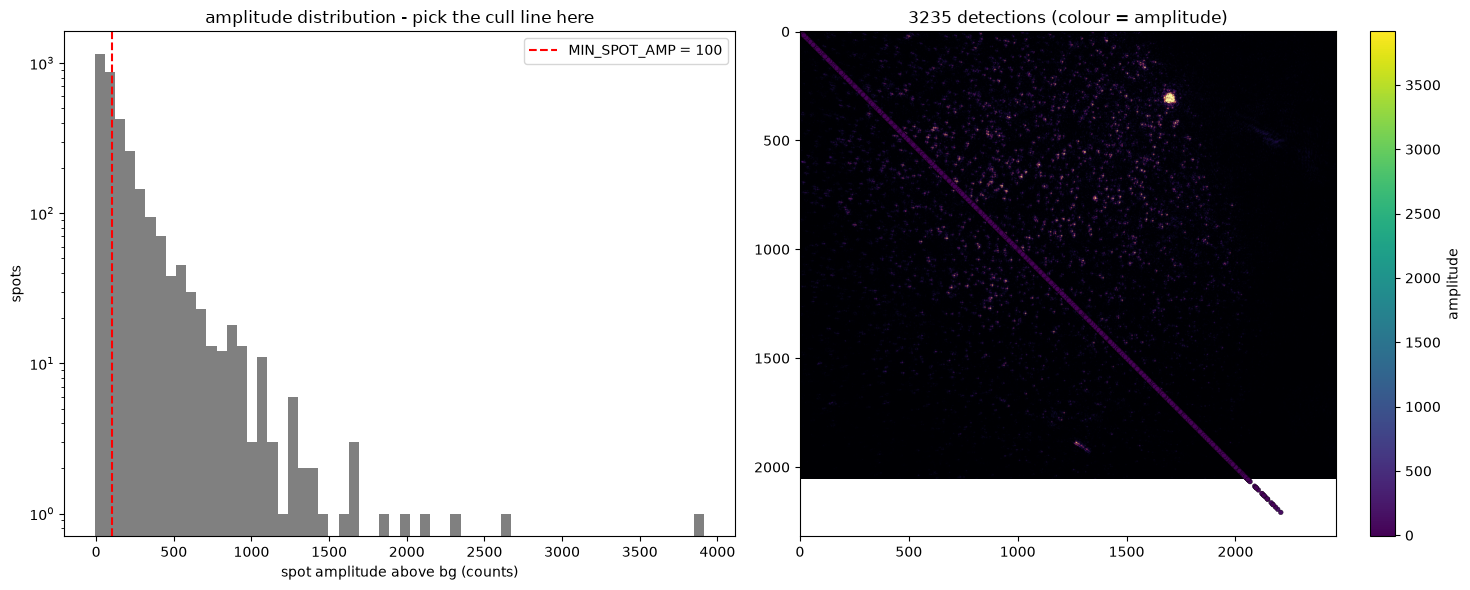

spots sorted by amplitude: index 0 = brightest. Use the magnifier below to inspect.


In [39]:
# --- 2b-1: amplitude histogram + full-field overlay coloured by amplitude ---
spots_sorted = sorted(spots, key=lambda s: -(mean_img[s[0], s[1]] - bg_level))
amps = np.array([mean_img[y, x] - bg_level for (y, x) in spots_sorted])
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].hist(amps, bins=60, color='0.5')
axs[0].axvline(MIN_SPOT_AMP, color='r', ls='--', label=f'MIN_SPOT_AMP = {MIN_SPOT_AMP}')
axs[0].set_yscale('log'); axs[0].set_xlabel('spot amplitude above bg (counts)')
axs[0].set_ylabel('spots'); axs[0].legend(); axs[0].set_title('amplitude distribution - pick the cull line here')
im = axs[1].imshow(mean_img, cmap='inferno', vmin=bg_level, vmax=bg_level + 10*np.median(amps))
sc = axs[1].scatter([x for _, x in spots_sorted], [y for _, y in spots_sorted],
                    s=12, c=amps, cmap='viridis', edgecolor='k', lw=0.2)
plt.colorbar(sc, ax=axs[1], label='amplitude')
axs[1].set_title(f'{len(spots_sorted)} detections (colour = amplitude)')
fig.tight_layout(); plt.show()
print('spots sorted by amplitude: index 0 = brightest. Use the magnifier below to inspect.')


In [40]:
# --- 2b-2: interactive MAGNIFIER (blocks until closed; run manually in Jupyter) ---
from ipywidgets import interact, IntSlider

def magnifier(i=0, zoom_half=12):
    """Zoomed view of detection #i (sorted by amplitude, brightest first)."""
    y, x = spots_sorted[i]
    amp = mean_img[y, x] - bg_level
    y0, y1 = max(0, y-zoom_half), min(mean_img.shape[0], y+zoom_half+1)
    x0, x1 = max(0, x-zoom_half), min(mean_img.shape[1], x+zoom_half+1)
    fig, axs = plt.subplots(1, 2, figsize=(11, 5))
    axs[0].imshow(mean_img, cmap='inferno', vmin=bg_level, vmax=bg_level+10*np.median(amps))
    axs[0].add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, color='cyan', lw=1))
    axs[0].plot(x, y, 'r+', ms=12, mew=1.5)
    axs[0].set_title(f'full field (spot #{i})', fontsize=9)
    axs[1].imshow(mean_img[y0:y1, x0:x1], cmap='inferno',
                  extent=[x0, x1, y1, y0], vmin=bg_level, vmax=bg_level+2*max(amp, 1))
    axs[1].plot(x, y, 'r+', ms=14, mew=1.5)
    axs[1].add_patch(plt.Circle((x, y), CROP_HALF, fill=False, color='cyan', lw=1, ls=':'))
    axs[1].add_patch(plt.Circle((x, y), CROP_HALF+1, fill=False, color='orange', lw=0.8, ls=':'))
    axs[1].set_title(f'#{i}: ({x},{y})  amp={amp:.0f} counts\n'
                     f'cyan = extraction crop, orange = bg annulus', fontsize=9)
    axs[1].set_xlabel('x'); axs[1].set_ylabel('y')
    fig.tight_layout(); plt.show()

# NOTE: blocks until the figure is closed - run manually in Jupyter, skipped by nbconvert
if INTERACTIVE:
    interact(magnifier,
             i=IntSlider(value=0, min=0, max=len(spots_sorted)-1,
                         description='spot #', continuous_update=False),
             zoom_half=IntSlider(value=12, min=6, max=60, description='zoom'))
else:
    print(f'{len(spots_sorted)} spots sorted by amplitude (brightest = #0). '
          'Set INTERACTIVE = True in CONFIG and rerun for the slider magnifier.')

3235 spots sorted by amplitude (brightest = #0). Set INTERACTIVE = True in CONFIG and rerun for the slider magnifier.


In [41]:
# --- 2b-2b: SPOT CHECKER - is a rod I can SEE being detected/kept? ---
# Put (y, x) pixel coordinates of visible rods into CHECK_POSITIONS (in CONFIG)
# and rerun this cell after section 3. It reports the nearest detection and,
# if it was extracted, its amplitude / DC / theta / quality.
def check_position(y, x):
    amp = mean_img[y, x] - bg_level
    dets = [(y - py)**2 + (x - px)**2 for py, px in spots]
    j = int(np.argmin(dets)); d = np.sqrt(dets[j])
    in_results = next((r for r in results if r['x'] == spots[j][1] and r['y'] == spots[j][0]), None)
    print(f"position (y={y}, x={x}): amp = {amp:.0f} counts above bg")
    if d <= 5:
        py, px = spots[j]
        print(f"  nearest detection: ({px}, {py}) at {d:.1f} px")
        if in_results is not None:
            r = in_results
            print(f"  extracted: dc_med={r['dc_med']:.0f}, r_mean={r['r_mean']:.2f}, "
                  f"theta_med={r['theta_med']:.1f}, iqr={r['theta_iqr']:.1f} -> quality {r['quality']}")
        else:
            print("  detected but NOT extracted (dropped by amplitude gate or stationarity check)")
    else:
        print(f"  NO detection within 5 px (nearest {d:.0f} px away) - the detector misses this object;"
              " try lowering BIG_K (large-blob pass) or DOG_K_STD")

for pos in CHECK_POSITIONS:
    check_position(*pos)
if not CHECK_POSITIONS:
    print("CHECK_POSITIONS is empty - add (y, x) pairs of rods you can see in CONFIG and rerun.")
print(f"({len(results)} spots were extracted this run)")

CHECK_POSITIONS is empty - add (y, x) pairs of rods you can see in CONFIG and rerun.
(1276 spots were extracted this run)


kept 1461, dropped 1774


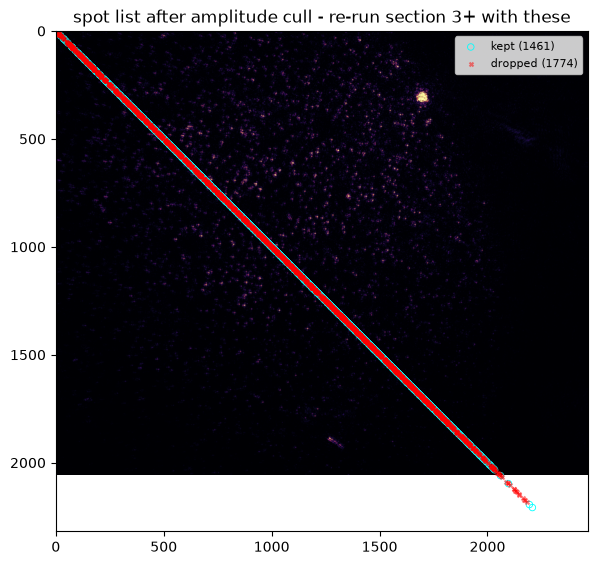

In [42]:
# --- 2b-3: cull by amplitude range, rebuild the spot list ---
# After inspecting, set the amplitude window that keeps real rods only:
AMP_MIN, AMP_MAX = MIN_SPOT_AMP, np.inf    # <-- edit after eyeballing, e.g. (150, 3000)

spots_kept = [(y, x) for (y, x) in spots_sorted
              if AMP_MIN <= mean_img[y, x] - bg_level <= AMP_MAX]
spots_dropped = [(y, x) for (y, x) in spots_sorted
                 if not (AMP_MIN <= mean_img[y, x] - bg_level <= AMP_MAX)]
print(f'kept {len(spots_kept)}, dropped {len(spots_dropped)}')

# NOTE: a long bright structure (fibre/edge) chain-detects along its whole length;
# if the amplitude gate drops it you get a red LINE here - that is expected.
fig, a = plt.subplots(figsize=(7.5, 6.5))
a.imshow(mean_img, cmap='inferno', vmin=bg_level, vmax=bg_level + 10*np.median(amps))
if spots_kept:
    a.scatter([x for _, x in spots_kept], [y for _, y in spots_kept], s=22,
              facecolors='none', edgecolors='cyan', lw=0.6,
              label=f'kept ({len(spots_kept)})')
if spots_dropped:
    a.scatter([x for _, x in spots_dropped], [y for _, y in spots_dropped], s=8, c='r',
              marker='x', alpha=0.5, label=f'dropped ({len(spots_dropped)})')
a.legend(fontsize=8); a.set_title('spot list after amplitude cull - re-run section 3+ with these')
plt.show()
# To use the culled list downstream:
#   stat_ok = check_stationarity(data, spots_kept)
#   spots_ok = [s for s, o in zip(spots_kept, stat_ok) if o]
#   results = extract_spot_theta(data, mean_img, spots_ok, halves=spot_halves(spots_ok, det_info))

### Plots: detection overlay, θ histogram, population anisotropy scatter, θ map

The **θ histogram** is the camera-paper deliverable: bare rods pile at θ ≈ 90°,
hinge rods peak at their open angles. The **anisotropy scatter** is the
many-rods version of the single-rod locus.


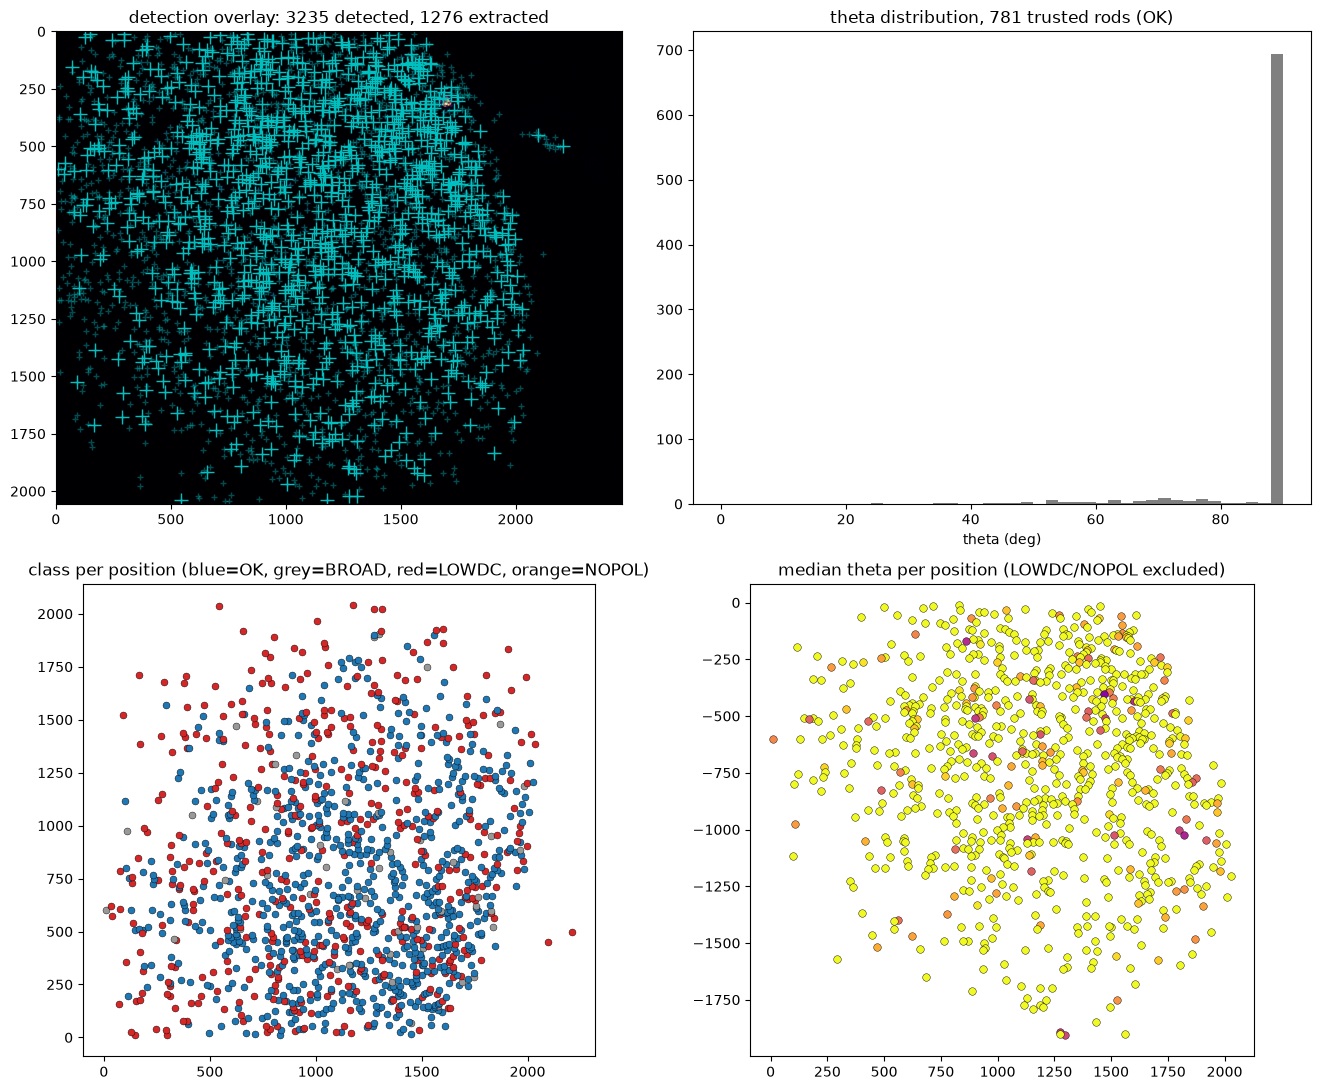

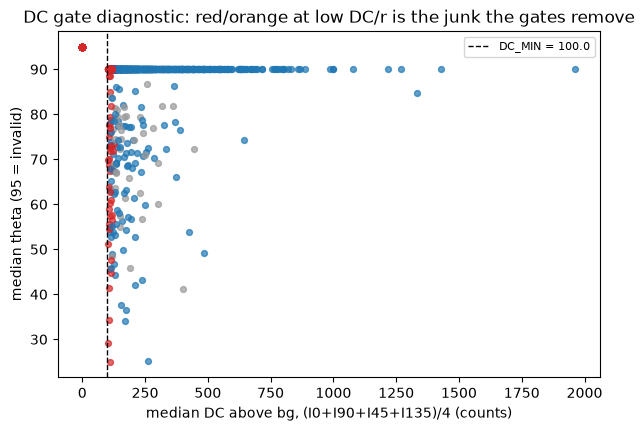

In [43]:
if SHOW_PLOTS:
    fig, axs = plt.subplots(2, 2, figsize=(13.5, 11))
    axs[0,0].imshow(mean_img, cmap='inferno')
    axs[0,0].plot([x for _, x in spots], [y for y, _ in spots], 'c+', ms=4, alpha=0.4)
    axs[0,0].plot([x for _, x in spots_ok], [y for y, _ in spots_ok], 'c+', ms=10)
    axs[0,0].set_title(f'detection overlay: {len(spots)} detected, {len(spots_ok)} extracted')
    # theta histogram of the TRUSTED rods only (OK = tight IQR + real DC + polarised)
    ths = [r['theta_med'] for r in results if r['quality'] == 'OK']
    axs[0,1].hist(ths, bins=np.arange(0, 92, 2), color='0.5')
    axs[0,1].set_xlabel('theta (deg)'); axs[0,1].set_title(f'theta distribution, {len(ths)} trusted rods (OK)')
    cols = {'OK': 'tab:blue', 'BROAD': '0.6', 'LOWDC': 'tab:red', 'NOPOL': 'tab:orange'}
    for r in results:
        axs[1,0].scatter(r['x'], r['y'], s=25, c=cols[r['quality']], edgecolor='k', lw=0.3)
    axs[1,0].set_title('class per position (blue=OK, grey=BROAD, red=LOWDC, orange=NOPOL)')
    axs[1,0].set_aspect('equal')
    for r in results:
        if r['quality'] in ('LOWDC', 'NOPOL'): continue
        axs[1,1].scatter(r['x'], -r['y'], s=30, c=r['theta_med'], cmap='plasma',
                         vmin=0, vmax=90, edgecolor='k', lw=0.3)
    axs[1,1].set_title('median theta per position (LOWDC/NOPOL excluded)')
    axs[1,1].set_aspect('equal')
    fig.tight_layout(); plt.show()
    # dc vs theta: the fake-90 population lives at dc ~ 0; real rods separate cleanly
    fig, a = plt.subplots(figsize=(7, 4.5))
    for r in results:
        a.scatter(r['dc_med'], r['theta_med'] if np.isfinite(r['theta_med']) else 95,
                  s=18, c=cols[r['quality']], alpha=0.7)
    a.axvline(DC_MIN, color='k', ls='--', lw=1, label=f'DC_MIN = {DC_MIN}')
    a.set_xlabel('median DC above bg, (I0+I90+I45+I135)/4 (counts)')
    a.set_ylabel('median theta (95 = invalid)'); a.legend(fontsize=8)
    a.set_title('DC gate diagnostic: red/orange at low DC/r is the junk the gates remove')
    plt.show()

## 4. Export per-spot CSV


In [44]:
import csv
out_csv = Path(OUTPUT_DIR); out_csv.mkdir(exist_ok=True)
csv_path = out_csv / (PATH.stem + '_spots.csv')
with open(csv_path, 'w', newline='') as f:
    if results:
        w = csv.DictWriter(f, fieldnames=list(results[0].keys()))
        w.writeheader(); w.writerows(results)
print('wrote', csv_path, f'({len(results)} rows)')

wrote framestack_survey_out\frame_stack_20260918-145406_spots.csv (1276 rows)


## 5. Folder loop: all framestacks → combined comparison

Run after single files look right. Each file contributes its tight-θ rods to the
combined histogram; overlay hinge vs bare recordings for the discriminator plot.


In [45]:
# Folder loop: per-file theta histogram, then the combined overlay
all_rods = []
file_thetas = {}          # {file_name: [theta_med per rod]}
for path in sorted(Path(FOLDER).glob(FILE_PATTERN)):
    print('processing', path.name, flush=True)
    try:
        data, mean_img, n_used = load_mean_image(path)
        smap, _ = build_smap(data)
        spots, det_info = detect_spots_multiscale(smap)
        bg_level = float(np.median(mean_img))
        spot_amps = np.array([mean_img[y, x] - bg_level for (y, x) in spots])
        spots_amp = [s for s, a in zip(spots, spot_amps) if a >= MIN_SPOT_AMP]
        stat_ok = check_stationarity(data, spots_amp)
        spots_ok = [s for s, o in zip(spots_amp, stat_ok) if o]
        results = extract_spot_theta(data, mean_img, spots_ok, halves=spot_halves(spots_ok, det_info))
        for r in results:
            r['file'] = path.stem
            r['quality'] = quality_of(r)
        ths_file = [r['theta_med'] for r in results if r['quality'] == 'OK']
        file_thetas[path.stem] = ths_file
        all_rods += [r for r in results if r['quality'] == 'OK']
        print(f'  {len(spots)} detected -> {len(spots_amp)} pass amp gate -> '
              f'{len(ths_file)} trusted rods', flush=True)
        del data, smap
        import gc; gc.collect()
    except Exception as e:
        print('  !! failed:', e)

# --- per-file histograms: one panel per file, shared bins ---
if file_thetas:
    names = list(file_thetas)
    ncol = 3
    nrow = int(np.ceil(len(names) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.6 * nrow),
                            sharex=True, sharey=True, squeeze=False)
    bins = np.arange(0, 92, 2)
    for k, name in enumerate(names):
        a = axs[k // ncol][k % ncol]
        a.hist(file_thetas[name], bins=bins, color='0.5')
        a.set_title(f'{name}  ({len(file_thetas[name])} rods)', fontsize=10)
        if k // ncol == nrow - 1: a.set_xlabel('theta (deg)')
        if k % ncol == 0: a.set_ylabel('rods')
    for k in range(len(names), nrow * ncol):
        axs[k // ncol][k % ncol].axis('off')
    fig.suptitle('theta distribution per file (trusted rods: tight IQR + real DC)', fontsize=12)
    fig.tight_layout(); plt.show()

    # --- combined overlay for direct comparison ---
    fig, a = plt.subplots(figsize=(10, 4.5))
    bins = np.arange(0, 92, 2)
    for name in names:
        a.hist(file_thetas[name], bins=bins, histtype='step', lw=1.6, label=f'{name} ({len(file_thetas[name])})')
    a.set_xlabel('theta (deg)'); a.set_ylabel('rods')
    a.set_title('theta distributions overlaid (per file)')
    a.legend(fontsize=8)
    plt.show()

import csv as csvmod
with open(out_csv / 'all_rods.csv', 'w', newline='') as f:
    if all_rods:
        w = csvmod.DictWriter(f, fieldnames=list(all_rods[0].keys()))
        w.writeheader(); w.writerows(all_rods)
print('wrote', out_csv / 'all_rods.csv')

processing frame_stack_20260918-145406.npy
  3235 detected -> 1461 pass amp gate -> 781 trusted rods
processing frame_stack_20260918-151106.npy
  4044 detected -> 1758 pass amp gate -> 480 trusted rods
processing frame_stack_20260918-151218.npy
  3193 detected -> 1541 pass amp gate -> 616 trusted rods
processing frame_stack_20260918-152241.npy
  2982 detected -> 1550 pass amp gate -> 720 trusted rods
processing frame_stack_20260918-152256.npy
  3006 detected -> 1531 pass amp gate -> 697 trusted rods
processing frame_stack_20260918-152740.npy


KeyboardInterrupt: 